In [1]:
import scanpy as sc
import scvi
import matplotlib.pyplot as plt

/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey_subsampleV2_QCmetric_scanpy.h5ad")

In [3]:
adata.obs["donor_multiome"] = adata.obs.Donor.astype(str) + "_" + adata.obs.Multiome.astype(str)

In [4]:
adata

AnnData object with n_obs × n_vars = 89118 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'donor_multiome'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Donor_colors', 'Location_colors', 'Multiome_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_

In [5]:
# Additional QC, parameters adopted from Hickey paper
sc.pp.filter_cells(adata, min_genes=400)

In [6]:
sc.pp.filter_cells(adata, max_genes=10000)

In [7]:
sc.pp.filter_cells(adata, max_counts=20000)

In [8]:
adata

AnnData object with n_obs × n_vars = 48966 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'donor_multiome'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Donor_colors', 'Location_colors', 'Multiome_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_

In [9]:
adata = adata[adata.obs.Multiome == "Yes"]  # snRNA-seq only

In [10]:
adata

View of AnnData object with n_obs × n_vars = 25538 × 21332
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'donor_multiome'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Donor_colors', 'Location_colors', 'Multiome_colors', 'hvg', 'log1p', 'neighbors', 'pca', 

In [12]:
# Store original
adata_ori = adata.copy()

In [13]:
# recompute highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Donor", subset=True)

/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [14]:
adata

AnnData object with n_obs × n_vars = 25538 × 2000
    obs: 'sample_id', 'barcode', 'SampleNameOnly', 'Donor', 'Multiome', 'Location', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'donor_multiome'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Donor_colors', 'Location_colors', 'Multiome_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_i

In [15]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="Donor")

In [16]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

In [17]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/mnt/nfs/EMBO/miniforge3/envs/scanpy2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 313/313: 100%|██████████| 313/313 [20:26<00:00,  3.67s/it, v_num=1, train_loss=770]

`Trainer.fit` stopped: `max_epochs=313` reached.


Epoch 313/313: 100%|██████████| 313/313 [20:26<00:00,  3.92s/it, v_num=1, train_loss=770]


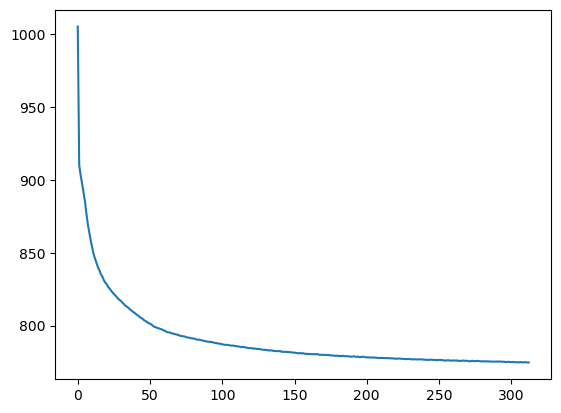

In [18]:
plt.plot(model.history["elbo_train"])

In [19]:
adata_ori.obsm["X_scVI"] = model.get_latent_representation()

In [20]:
sc.pp.neighbors(adata_ori, use_rep="X_scVI")

In [21]:
sc.tl.umap(adata_ori)

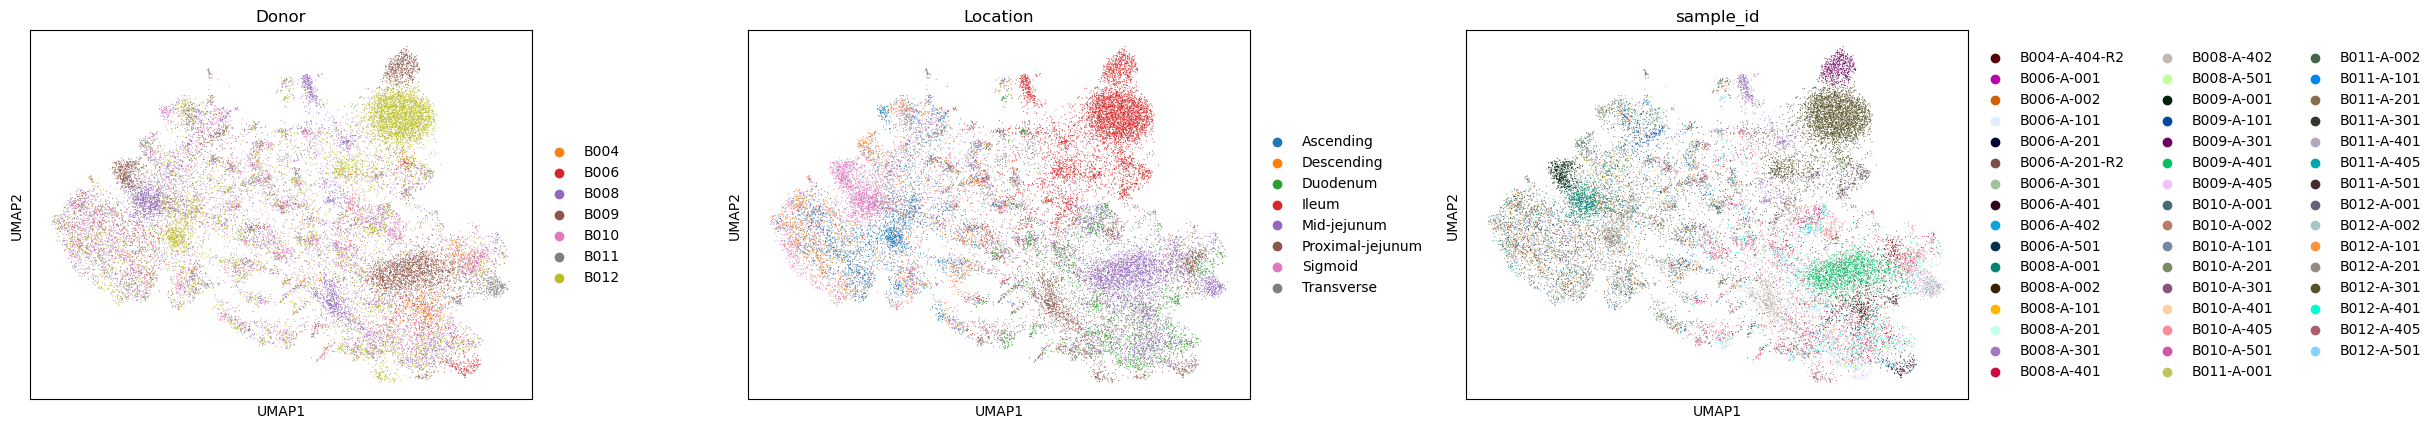

In [22]:
sc.pl.umap(
    adata_ori,
    color=["Donor", "Location", "sample_id"],
    size=2,
    wspace=0.3
)

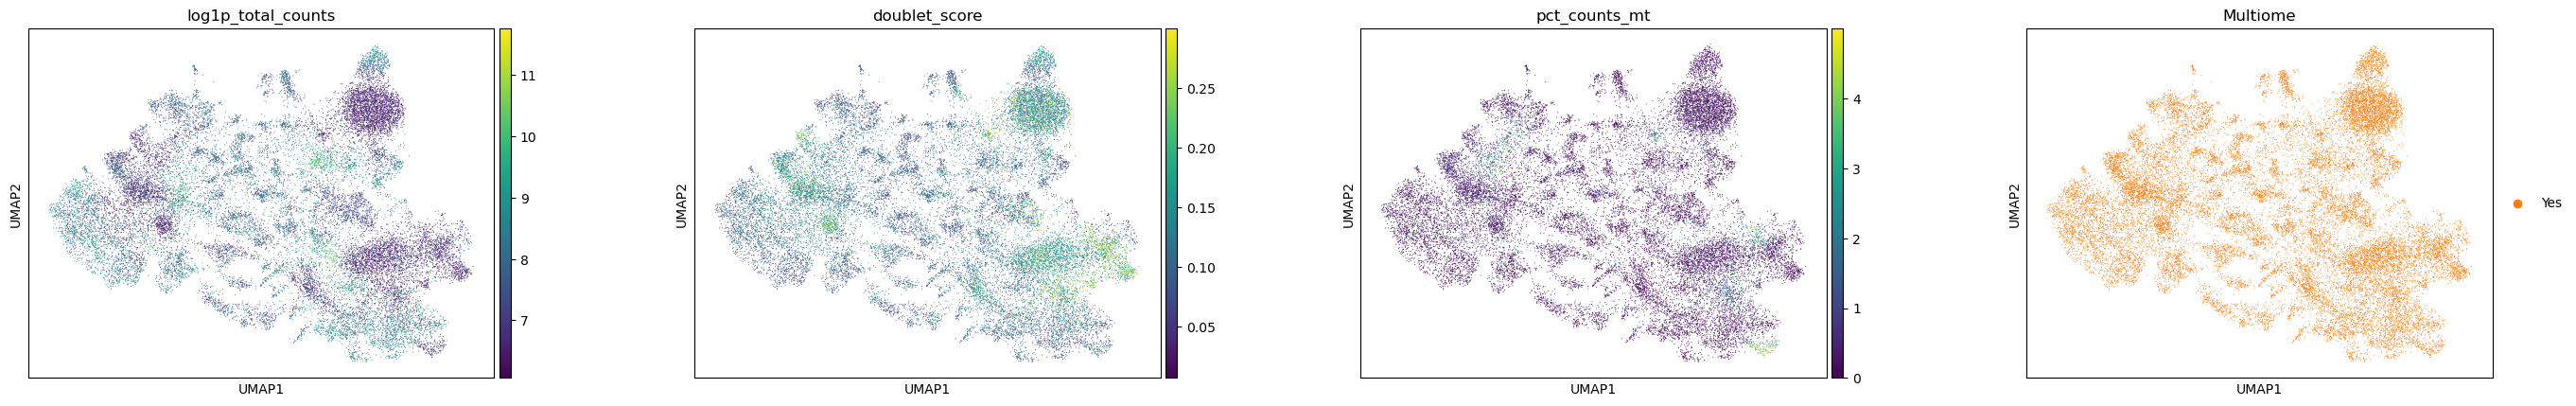

In [23]:
# Plot technical variables
sc.pl.umap(
    adata_ori,
    color=["log1p_total_counts", "doublet_score", "pct_counts_mt", "Multiome"],
    size=2,
    wspace=0.3
)

In [24]:
adata_ori.write_h5ad("/mnt/nfs/EMBO/Integration/data/Hickey2023/hickey_subsampleV2_QCmetric_scanpy_scvi.h5ad")